# Lecture 27: Convexity

**Source span read.** I extracted physical PDF pages 178-184 with `pdftotext`. The page text begins with **Lecture 27 / Convexity** on printed page 168, continues through the CP examples on printed page 172, and then gives the Homework 21 connectedness scaffold on printed pages 173-174. The earlier inventory entry `182-188` lands late in the lecture and spills into Lecture 28, so this notebook uses the page headers and content rather than that stale physical-page span.

**Goal.** Understand the Atiyah-Guillemin-Sternberg convexity theorem as a visible statement about moment maps for compact Hamiltonian torus actions: connected fibers force convex moment images, and the whole image is the convex hull of fixed-point images.

The lecture has three layers. First, the proof reduces convexity in `R^m` to connectedness for `(m-1)`-subtori and one-dimensional line segments. Second, fixed points become the vertices that support the polytope. Third, effective actions impose dimension and fixed-point lower bounds, leading directly into the toric-manifold examples of the next lecture. The notebook below turns those layers into a proof graph, concrete CP examples, a slicing picture, and executable checks.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import ConvexHull, Delaunay


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-27"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in (FIG_DIR, HTML_DIR, CHECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace('\\', '/')


def write_json(path, payload):
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-27


## Library Routing

NetworkX is used for the convexity proof route because the theorem depends on connected level sets, fixed-point data, and convex-hull claims. Matplotlib is used for CP1, CP2, CP3 moment polytopes, subtorus slicing, and effective-action strata because these are moment-image and face-incidence pictures. Plotly supplies the simplex lab so barycentric coordinates and moment-image membership can be varied directly. SciPy spatial predicates and NumPy checks verify convex-hull containment, projected-level constancy, and the dimension/fixed-point bounds from the lecture and Homework 21.

## Compact Visualization Storyboard

The source-specific storyboard is deliberately small. Each item corresponds to a theorem move or example in the extracted pages.

| Item | Representation | Inspection target | Check |
| --- | --- | --- | --- |
| Convexity proof route | Directed graph | Which inputs prove connected levels, convex image, and fixed-point hull | graph is acyclic and reaches the theorem claims |
| CP moment polytopes | Static coordinate plots | CP1 gives an interval, CP2 a triangle, CP3 a tetrahedron; fixed points are vertices | sampled moment values lie in the convex hull of fixed-point images |
| Subtorus slicing | 2D affine slice picture | For `m=2`, a connected level of a circle subtorus maps to a line and hits every segment point | sample points have constant `A^T mu` and cover the segment endpoints |
| Effective-action strata | CP2 triangle strata diagram | Interior points have trivial stabilizer, edges have circle stabilizer, vertices are fixed | face dimensions match stabilizer dimensions and `dim M >= 2m` |
| Homework 21 bridge | JSON proof ledger | Connectedness rests on invariant almost-complex structures and Morse-Bott even index | every dependency used by the convexity proof is present |

Library route: Matplotlib is the right durable renderer for the 2D proof and polytope diagrams; NetworkX is used only for the proof dependency graph; Plotly is reserved for the interactive simplex lab because the learner benefits from rotating CP3's tetrahedral moment image.

In [2]:
source_span = {
    "lecture": "Lecture 27: Convexity",
    "pdf_extraction_tool": "pdftotext",
    "physical_pdf_pages_read": "178-184",
    "printed_pages_read": "168-174",
    "lecture_pages": "168-172",
    "homework_pages_used_for_connectedness_scaffold": "173-174",
    "source_map_note": "The inventory span 182-188 starts at printed page 172 and spills into Lecture 28; page headers show 178-184 is the usable Convexity span."
}

storyboard = {
    "chapter_goal": "Read moment-map convexity as a visible fixed-point and connected-fiber theorem for Hamiltonian torus actions.",
    "source_span_read": source_span,
    "concept_inventory": [
        "Atiyah-Guillemin-Sternberg convexity theorem for compact Hamiltonian torus actions",
        "induction statements A_m for connected fibers and B_m for convex images",
        "integer injective matrix A selecting an (m-1)-subtorus and projected moment map A^T mu",
        "fixed-point components C_j with constant moment values eta_j",
        "separating functional with rationally independent direction X",
        "effective actions, lower bound m+1 fixed points, and dim M >= 2m",
        "examples: S2 height interval, CP1 interval, CP2 triangle, CP3 simplex, CP1 x CP1 rectangle"
    ],
    "visual_sequence": [
        {
            "concept": "convexity proof route",
            "representation": "NetworkX directed dependency graph rendered with Matplotlib",
            "artifact": "artifacts/lecture-27/figures/lecture-27-convexity-proof-route.png",
            "inspection_target": "follow A_m, B_m, subtorus slicing, and fixed-point hull dependencies",
            "validation": "directed acyclic graph; theorem nodes are reachable from source hypotheses"
        },
        {
            "concept": "CP moment polytopes",
            "representation": "Matplotlib interval, triangle, and tetrahedron projection",
            "artifact": "artifacts/lecture-27/figures/lecture-27-cp-moment-polytopes.png",
            "inspection_target": "fixed-point images are the vertices and sampled moment values fill their convex hulls",
            "validation": "Delaunay/hull containment residuals for CP2 and CP3 samples"
        },
        {
            "concept": "subtorus slicing proof move",
            "representation": "Matplotlib affine line slice inside the CP2 triangle",
            "artifact": "artifacts/lecture-27/figures/lecture-27-subtorus-slicing.png",
            "inspection_target": "a connected projected level maps into a line and contains every segment value",
            "validation": "all slice samples have constant A^T mu within tolerance"
        },
        {
            "concept": "effective-action strata",
            "representation": "Matplotlib face-stratified CP2 moment triangle",
            "artifact": "artifacts/lecture-27/figures/lecture-27-effective-strata.png",
            "inspection_target": "interior, edge, and vertex strata show stabilizer growth toward fixed points",
            "validation": "CP2 has m+1 fixed points and dim CP2 = 2m"
        },
        {
            "concept": "interactive simplex lab",
            "representation": "Plotly HTML with CP2 and CP3 moment images",
            "artifact": "artifacts/lecture-27/interactive/lecture-27-moment-simplex-lab.html",
            "inspection_target": "rotate the CP3 tetrahedron and compare it with the CP2 triangular face",
            "validation": "HTML file exists and the same hull checks pass in JSON"
        }
    ],
    "proof_visualization_strategy": "Use a dependency graph for the global theorem, a line-slice diagram for the induction step A_{m-1} => B_m, and a separating-functional ledger for the fixed-point convex-hull converse.",
    "computational_checks": [
        "convex hull containment for sampled CP2 and CP3 moment-map values",
        "constant projected moment value along the selected subtorus slice",
        "fixed-point counts and dimension inequality for the effective CP2 action",
        "artifact existence and nonzero file size"
    ]
}
write_json(CHECK_DIR / "source-span.json", source_span)
write_json(CHECK_DIR / "visual-storyboard.json", storyboard)
storyboard["visual_sequence"]

[{'concept': 'convexity proof route',
  'representation': 'NetworkX directed dependency graph rendered with Matplotlib',
  'artifact': 'artifacts/lecture-27/figures/lecture-27-convexity-proof-route.png',
  'inspection_target': 'follow A_m, B_m, subtorus slicing, and fixed-point hull dependencies',
  'validation': 'directed acyclic graph; theorem nodes are reachable from source hypotheses'},
 {'concept': 'CP moment polytopes',
  'representation': 'Matplotlib interval, triangle, and tetrahedron projection',
  'artifact': 'artifacts/lecture-27/figures/lecture-27-cp-moment-polytopes.png',
  'inspection_target': 'fixed-point images are the vertices and sampled moment values fill their convex hulls',
  'validation': 'Delaunay/hull containment residuals for CP2 and CP3 samples'},
 {'concept': 'subtorus slicing proof move',
  'representation': 'Matplotlib affine line slice inside the CP2 triangle',
  'artifact': 'artifacts/lecture-27/figures/lecture-27-subtorus-slicing.png',
  'inspection_targ

## The Theorem As A Dependency Graph

The convexity theorem packages three claims: fibers of the moment map are connected, the moment image is convex, and the image is the convex hull of fixed-point images. The proof on the extracted pages treats connectedness as the hard input. Once connectedness for `(m-1)`-dimensional subtori is available, an affine line-slice argument produces convexity in `R^m`. Then a separating functional rules out any point outside the convex hull of fixed-point values.

The graph below is not a proof replacement; it is a proof index. Read an arrow as "this ingredient is used to certify that next claim." The Homework 21 nodes are included because the lecture explicitly sends the connectedness induction step there.

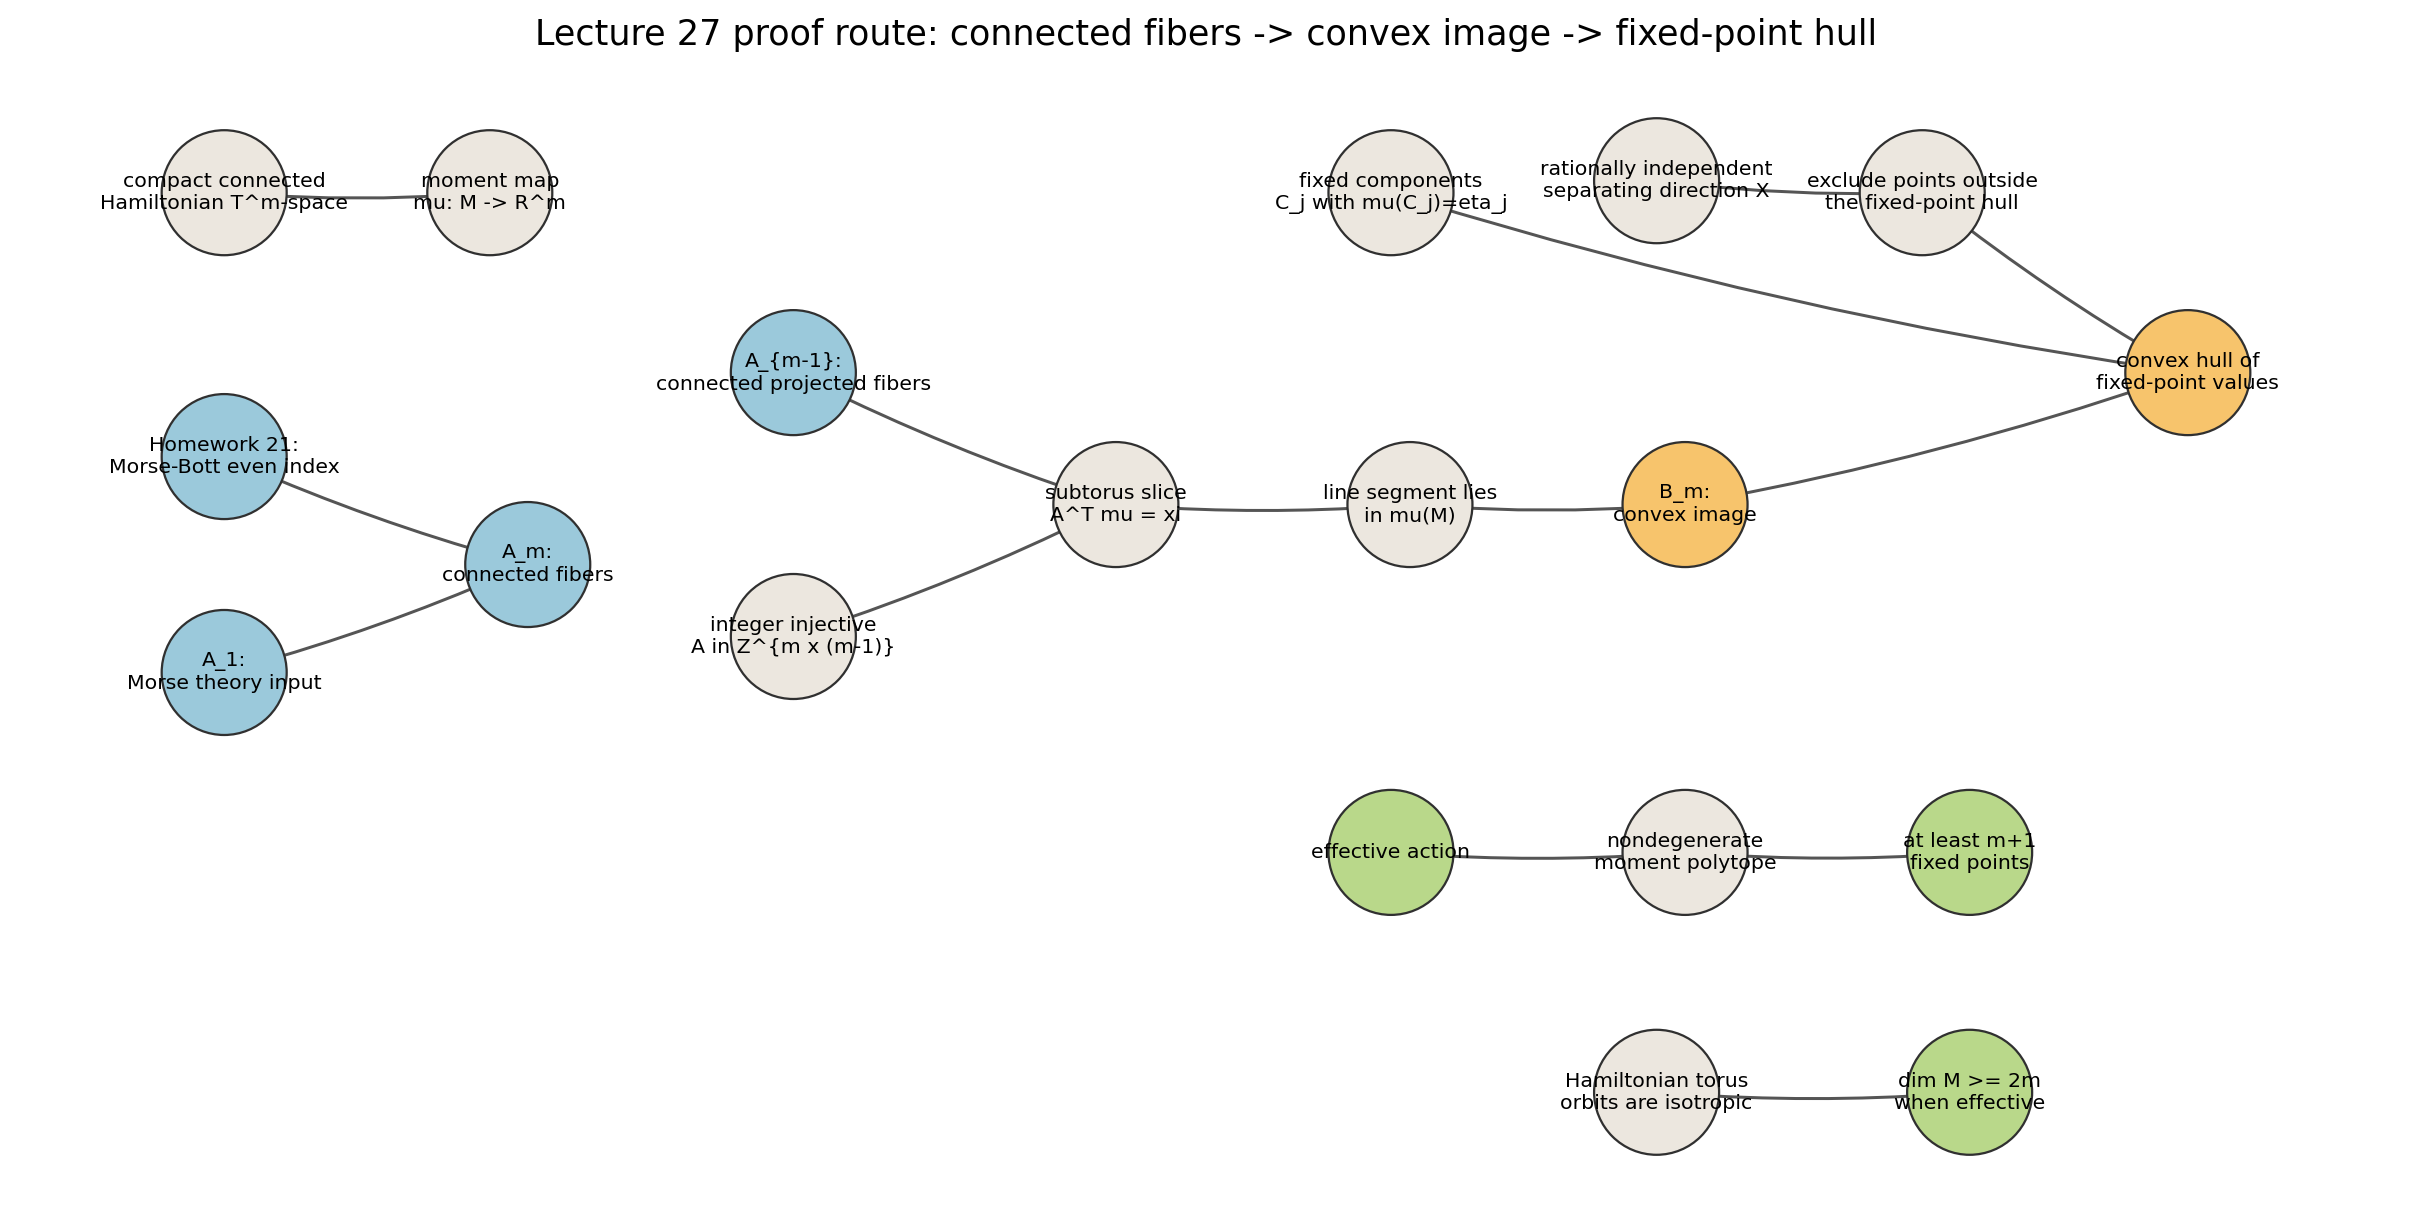

{'is_directed_acyclic_graph': True,
 'node_count': 19,
 'edge_count': 14,
 'reachable_theorem_claims': {'convex_image_from_slice': True,
  'fixed_hull_from_separation': True,
  'effective_fixed_point_bound': True,
  'effective_dimension_bound': True}}

In [3]:
G = nx.DiGraph()
edges = [
    ("compact connected\nHamiltonian T^m-space", "moment map\nmu: M -> R^m"),
    ("Homework 21:\nMorse-Bott even index", "A_m:\nconnected fibers"),
    ("A_1:\nMorse theory input", "A_m:\nconnected fibers"),
    ("A_{m-1}:\nconnected projected fibers", "subtorus slice\nA^T mu = xi"),
    ("integer injective\nA in Z^{m x (m-1)}", "subtorus slice\nA^T mu = xi"),
    ("subtorus slice\nA^T mu = xi", "line segment lies\nin mu(M)"),
    ("line segment lies\nin mu(M)", "B_m:\nconvex image"),
    ("B_m:\nconvex image", "convex hull of\nfixed-point values"),
    ("fixed components\nC_j with mu(C_j)=eta_j", "convex hull of\nfixed-point values"),
    ("rationally independent\nseparating direction X", "exclude points outside\nthe fixed-point hull"),
    ("exclude points outside\nthe fixed-point hull", "convex hull of\nfixed-point values"),
    ("effective action", "nondegenerate\nmoment polytope"),
    ("nondegenerate\nmoment polytope", "at least m+1\nfixed points"),
    ("Hamiltonian torus\norbits are isotropic", "dim M >= 2m\nwhen effective"),
]
G.add_edges_from(edges)

pos = {
    "compact connected\nHamiltonian T^m-space": (0, 3.0),
    "moment map\nmu: M -> R^m": (1.4, 3.0),
    "Homework 21:\nMorse-Bott even index": (0, 1.9),
    "A_1:\nMorse theory input": (0, 1.0),
    "A_m:\nconnected fibers": (1.6, 1.45),
    "A_{m-1}:\nconnected projected fibers": (3.0, 2.25),
    "integer injective\nA in Z^{m x (m-1)}": (3.0, 1.15),
    "subtorus slice\nA^T mu = xi": (4.7, 1.7),
    "line segment lies\nin mu(M)": (6.25, 1.7),
    "B_m:\nconvex image": (7.7, 1.7),
    "fixed components\nC_j with mu(C_j)=eta_j": (6.15, 3.0),
    "rationally independent\nseparating direction X": (7.55, 3.05),
    "exclude points outside\nthe fixed-point hull": (8.95, 3.0),
    "convex hull of\nfixed-point values": (10.35, 2.25),
    "effective action": (6.15, 0.25),
    "nondegenerate\nmoment polytope": (7.7, 0.25),
    "at least m+1\nfixed points": (9.2, 0.25),
    "Hamiltonian torus\norbits are isotropic": (7.55, -0.75),
    "dim M >= 2m\nwhen effective": (9.2, -0.75),
}

fig, ax = plt.subplots(figsize=(13.5, 6.8))
node_colors = []
for node in G.nodes:
    if "B_m" in node or "convex hull" in node:
        node_colors.append("#f7c46c")
    elif "Homework" in node or "A_" in node:
        node_colors.append("#9bc9db")
    elif "effective" in node or "dim" in node or "fixed points" in node:
        node_colors.append("#b9d88a")
    else:
        node_colors.append("#ece7df")

nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, edge_color="#555", width=1.2, connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, edgecolors="#303030", node_size=2500, linewidths=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.2, font_family="DejaVu Sans")
ax.set_title("Lecture 27 proof route: connected fibers -> convex image -> fixed-point hull", fontsize=14, pad=16)
ax.set_axis_off()
fig.tight_layout()
proof_route_path = FIG_DIR / "lecture-27-convexity-proof-route.png"
fig.savefig(proof_route_path, dpi=180, bbox_inches="tight")
plt.close(fig)

proof_checks = {
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "reachable_theorem_claims": {
        "convex_image_from_slice": nx.has_path(G, "subtorus slice\nA^T mu = xi", "B_m:\nconvex image"),
        "fixed_hull_from_separation": nx.has_path(G, "rationally independent\nseparating direction X", "convex hull of\nfixed-point values"),
        "effective_fixed_point_bound": nx.has_path(G, "effective action", "at least m+1\nfixed points"),
        "effective_dimension_bound": nx.has_path(G, "Hamiltonian torus\norbits are isotropic", "dim M >= 2m\nwhen effective")
    }
}
write_json(CHECK_DIR / "proof-route-checks.json", proof_checks)
display_artifact(proof_route_path, width=900)
proof_checks

## Moment Polytopes In The Examples

For the standard torus action on projective space, the moment map depends only on normalized squared norms. For `CP^n`, write

`rho_j = |z_j|^2 / (|z_0|^2 + ... + |z_n|^2)`.

In the convention used by the lecture examples, the nonzero moment coordinates are `-1/2 rho_j` for `j >= 1`. Thus the fixed points map to the vertices of a simplex: an interval for `CP1`, a triangle for `CP2`, and a tetrahedron for `CP3`. The plot shows the fixed-point images and a deterministic grid of sampled moment values. The check records that all samples stay inside the convex hull.

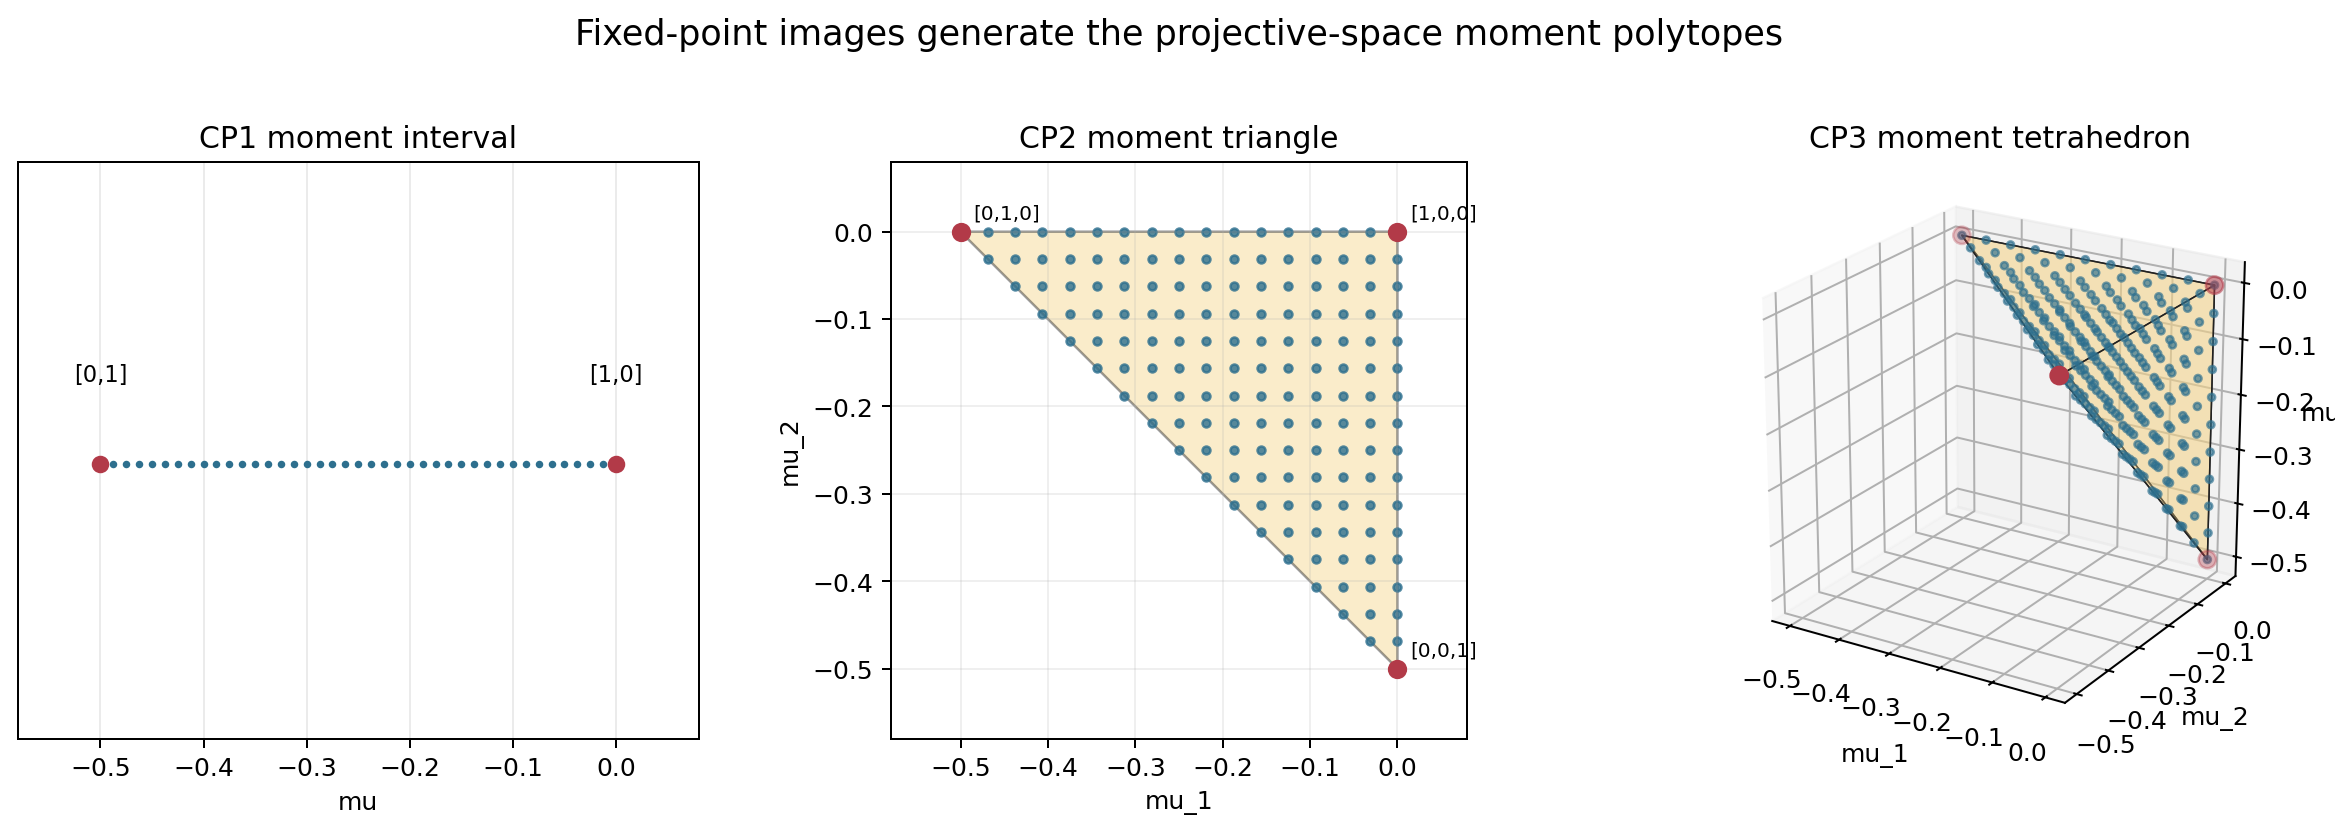

{'CP1': {'interval': [-0.5, 0.0],
  'sample_min': -0.5,
  'sample_max': -0.0,
  'inside_interval': True},
 'CP2': {'fixed_point_images': [[0.0, 0.0], [-0.5, 0.0], [0.0, -0.5]],
  'sample_count': 153,
  'all_samples_inside_fixed_point_hull': True},
 'CP3': {'fixed_point_images': [[0.0, 0.0, 0.0],
   [-0.5, 0.0, 0.0],
   [0.0, -0.5, 0.0],
   [0.0, 0.0, -0.5]],
  'sample_count': 286,
  'all_samples_inside_fixed_point_hull': True,
  'simplex_inequalities': 'mu_i <= 0 and sum(mu_i) >= -1/2'},
 'CP1_times_CP1': {'moment_polytope': 'rectangle [-1/2, 0] x [-1/2, 0]',
  'fixed_point_count': 4}}

In [4]:
def cp_moment_samples(n, grid=9):
    """Moment samples for the standard T^n action on CP^n in lecture convention."""
    if n == 1:
        rho1 = np.linspace(0, 1, grid)
        return (-0.5 * rho1)[:, None]
    samples = []
    def rec(prefix, remaining, slots):
        if slots == 1:
            vals = prefix + [remaining]
            total = sum(vals)
            rho = np.array(vals, dtype=float) / total if total else np.zeros(len(vals))
            samples.append(-0.5 * rho[1:])
            return
        for k in range(remaining + 1):
            rec(prefix + [k], remaining - k, slots - 1)
    rec([], grid, n + 1)
    return np.array(samples)

vertices = {
    "CP1": np.array([[0.0], [-0.5]]),
    "CP2": np.array([[0.0, 0.0], [-0.5, 0.0], [0.0, -0.5]]),
    "CP3": np.array([[0.0, 0.0, 0.0], [-0.5, 0.0, 0.0], [0.0, -0.5, 0.0], [0.0, 0.0, -0.5]]),
}
cp1_samples = cp_moment_samples(1, 41)
cp2_samples = cp_moment_samples(2, 16)
cp3_samples = cp_moment_samples(3, 10)

tri = Delaunay(vertices["CP2"])
cp2_inside = bool(np.all(tri.find_simplex(cp2_samples) >= 0))
# CP3 simplex check: barycentric coordinates are nonpositive coordinates with sum >= -1/2.
cp3_nonpositive = bool(np.all(cp3_samples <= 1e-12))
cp3_sum_bound = bool(np.all(cp3_samples.sum(axis=1) >= -0.5 - 1e-12))
cp3_inside = cp3_nonpositive and cp3_sum_bound

fig = plt.figure(figsize=(13.2, 4.5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(cp1_samples[:, 0], np.zeros_like(cp1_samples[:, 0]), '.', color="#2d6f8e", ms=4, label="samples")
ax1.scatter(vertices["CP1"][:, 0], [0, 0], color="#b23a48", zorder=3, label="fixed points")
for x, label in zip(vertices["CP1"][:, 0], ["[1,0]", "[0,1]"]):
    ax1.text(x, 0.06, label, ha="center", fontsize=9)
ax1.set_title("CP1 moment interval")
ax1.set_xlim(-0.58, 0.08)
ax1.set_ylim(-0.2, 0.22)
ax1.set_yticks([])
ax1.set_xlabel("mu")
ax1.grid(axis="x", alpha=0.25)

ax2 = fig.add_subplot(1, 3, 2)
tri_patch = Polygon(vertices["CP2"], closed=True, facecolor="#f5d58a", edgecolor="#222", alpha=0.45)
ax2.add_patch(tri_patch)
ax2.scatter(cp2_samples[:, 0], cp2_samples[:, 1], s=10, color="#2d6f8e", alpha=0.8)
ax2.scatter(vertices["CP2"][:, 0], vertices["CP2"][:, 1], color="#b23a48", s=45, zorder=3)
for xy, label in zip(vertices["CP2"], ["[1,0,0]", "[0,1,0]", "[0,0,1]"]):
    ax2.text(xy[0] + 0.015, xy[1] + 0.015, label, fontsize=8)
ax2.set_title("CP2 moment triangle")
ax2.set_aspect("equal")
ax2.set_xlim(-0.58, 0.08)
ax2.set_ylim(-0.58, 0.08)
ax2.set_xlabel("mu_1")
ax2.set_ylabel("mu_2")
ax2.grid(alpha=0.2)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
hull = ConvexHull(vertices["CP3"])
faces = [vertices["CP3"][simplex] for simplex in hull.simplices]
face_collection = Poly3DCollection(faces, facecolors="#f5d58a", edgecolors="#222", linewidths=0.6, alpha=0.35)
ax3.add_collection3d(face_collection)
ax3.scatter(cp3_samples[:, 0], cp3_samples[:, 1], cp3_samples[:, 2], color="#2d6f8e", s=8, alpha=0.65)
ax3.scatter(vertices["CP3"][:, 0], vertices["CP3"][:, 1], vertices["CP3"][:, 2], color="#b23a48", s=48)
ax3.set_title("CP3 moment tetrahedron")
ax3.set_xlabel("mu_1")
ax3.set_ylabel("mu_2")
ax3.set_zlabel("mu_3")
ax3.view_init(elev=22, azim=-58)
ax3.set_box_aspect((1, 1, 1))

fig.suptitle("Fixed-point images generate the projective-space moment polytopes", fontsize=14, y=1.02)
fig.tight_layout()
cp_path = FIG_DIR / "lecture-27-cp-moment-polytopes.png"
fig.savefig(cp_path, dpi=180, bbox_inches="tight")
plt.close(fig)

moment_checks = {
    "CP1": {
        "interval": [-0.5, 0.0],
        "sample_min": float(cp1_samples.min()),
        "sample_max": float(cp1_samples.max()),
        "inside_interval": bool(cp1_samples.min() >= -0.5 - 1e-12 and cp1_samples.max() <= 1e-12)
    },
    "CP2": {
        "fixed_point_images": vertices["CP2"].tolist(),
        "sample_count": int(len(cp2_samples)),
        "all_samples_inside_fixed_point_hull": cp2_inside
    },
    "CP3": {
        "fixed_point_images": vertices["CP3"].tolist(),
        "sample_count": int(len(cp3_samples)),
        "all_samples_inside_fixed_point_hull": cp3_inside,
        "simplex_inequalities": "mu_i <= 0 and sum(mu_i) >= -1/2"
    },
    "CP1_times_CP1": {
        "moment_polytope": "rectangle [-1/2, 0] x [-1/2, 0]",
        "fixed_point_count": 4
    }
}
write_json(CHECK_DIR / "moment-polytope-checks.json", moment_checks)
display_artifact(cp_path, width=900)
moment_checks

## The Subtorus Slice Behind Convexity

The proof of convexity uses an integer matrix `A` with one-dimensional kernel after transposition. In `R^2`, this is easy to see. Pick `A = (1, -1)^T`; then `A^T mu = mu_1 - mu_2` is constant on a projected moment-map level. The connectedness theorem for that circle subtorus says the preimage of the level is connected. Its image under `mu` therefore moves along a line, and a connected subset of a line that contains two endpoint values contains every value between them.

The plot below shows the line `mu_1 - mu_2 = 0` through the CP2 moment triangle. The check does the unglamorous part: every sampled point has the same projected moment value, and the midpoint really lies on the segment.

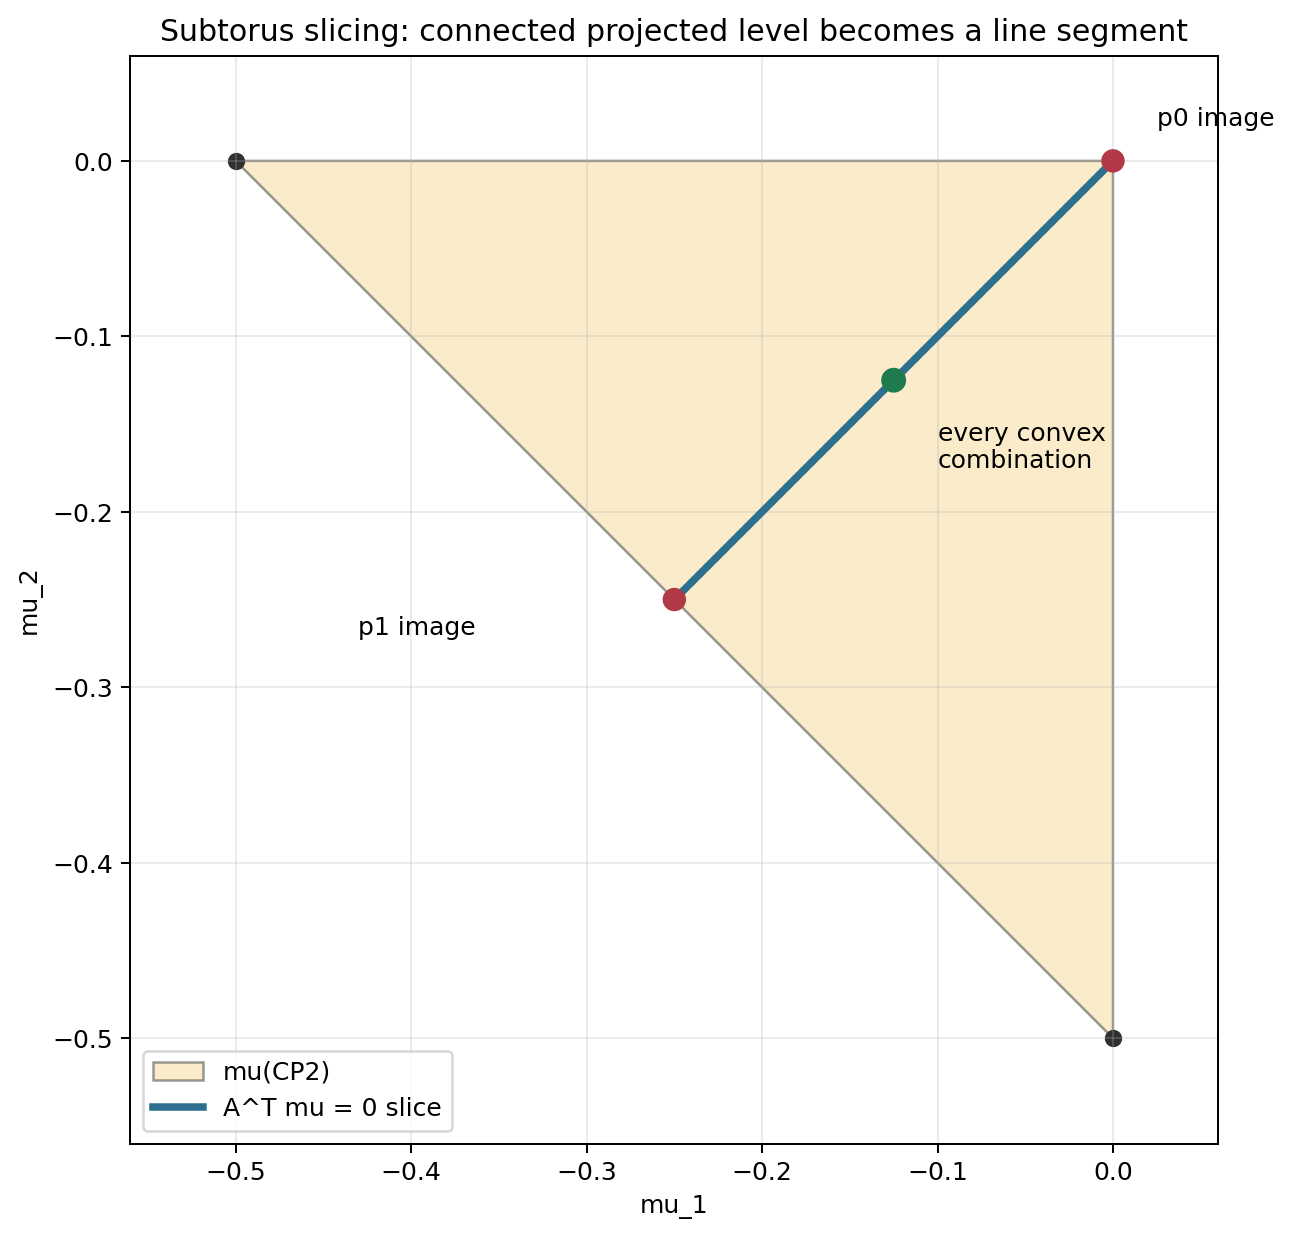

{'A_vector': [1.0, -1.0],
 'projected_level_value': 0.0,
 'max_projected_level_spread': 0.0,
 'midpoint_on_segment': True,
 'sample_count': 61,
 'inside_CP2_moment_triangle': True}

In [5]:
A = np.array([1.0, -1.0])
segment_t = np.linspace(0, 1, 61)
p0 = np.array([0.0, 0.0])
p1 = np.array([-0.25, -0.25])
slice_points = (1 - segment_t)[:, None] * p0 + segment_t[:, None] * p1
projected_values = slice_points @ A
midpoint = 0.5 * (p0 + p1)

fig, ax = plt.subplots(figsize=(7.4, 7.0))
tri_patch = Polygon(vertices["CP2"], closed=True, facecolor="#f5d58a", edgecolor="#222", alpha=0.45, label="mu(CP2)")
ax.add_patch(tri_patch)
ax.plot(slice_points[:, 0], slice_points[:, 1], color="#2d6f8e", lw=3, label="A^T mu = 0 slice")
ax.scatter([p0[0], p1[0], midpoint[0]], [p0[1], p1[1], midpoint[1]], color=["#b23a48", "#b23a48", "#1f7a4d"], s=[70, 70, 80], zorder=3)
ax.annotate("p0 image", p0 + np.array([0.025, 0.02]), fontsize=10)
ax.annotate("p1 image", p1 + np.array([-0.18, -0.02]), fontsize=10)
ax.annotate("every convex\ncombination", midpoint + np.array([0.025, -0.05]), fontsize=10)
for xy in vertices["CP2"]:
    ax.scatter([xy[0]], [xy[1]], color="#303030", s=35)
ax.set_title("Subtorus slicing: connected projected level becomes a line segment")
ax.set_xlabel("mu_1")
ax.set_ylabel("mu_2")
ax.set_aspect("equal")
ax.set_xlim(-0.56, 0.06)
ax.set_ylim(-0.56, 0.06)
ax.grid(alpha=0.25)
ax.legend(loc="lower left")
fig.tight_layout()
slice_path = FIG_DIR / "lecture-27-subtorus-slicing.png"
fig.savefig(slice_path, dpi=180, bbox_inches="tight")
plt.close(fig)

slice_checks = {
    "A_vector": A.tolist(),
    "projected_level_value": float(projected_values[0]),
    "max_projected_level_spread": float(np.max(projected_values) - np.min(projected_values)),
    "midpoint_on_segment": bool(np.allclose(midpoint, np.array([-0.125, -0.125]))),
    "sample_count": int(len(slice_points)),
    "inside_CP2_moment_triangle": bool(np.all(tri.find_simplex(slice_points) >= 0))
}
write_json(CHECK_DIR / "subtorus-slicing-checks.json", slice_checks)
display_artifact(slice_path, width=700)
slice_checks

## Effective Actions And Stabilizer Strata

The lecture then explains what effectiveness buys. If a `T^m` action is effective, the moment polytope is nondegenerate, so it must have at least `m+1` vertices. Those vertices come from fixed points. Separately, effective torus actions have `m`-dimensional orbits somewhere; Hamiltonian torus orbits are isotropic, so `m <= dim(M)/2`.

For `CP2`, `m=2` and `dim_R CP2 = 4`, so the bound is sharp. The triangle also shows stabilizers: the interior has free `T^2` orbits, edges have an `S^1` stabilizer, and vertices are fixed by all of `T^2`. This is exactly the visual prototype for a toric manifold.

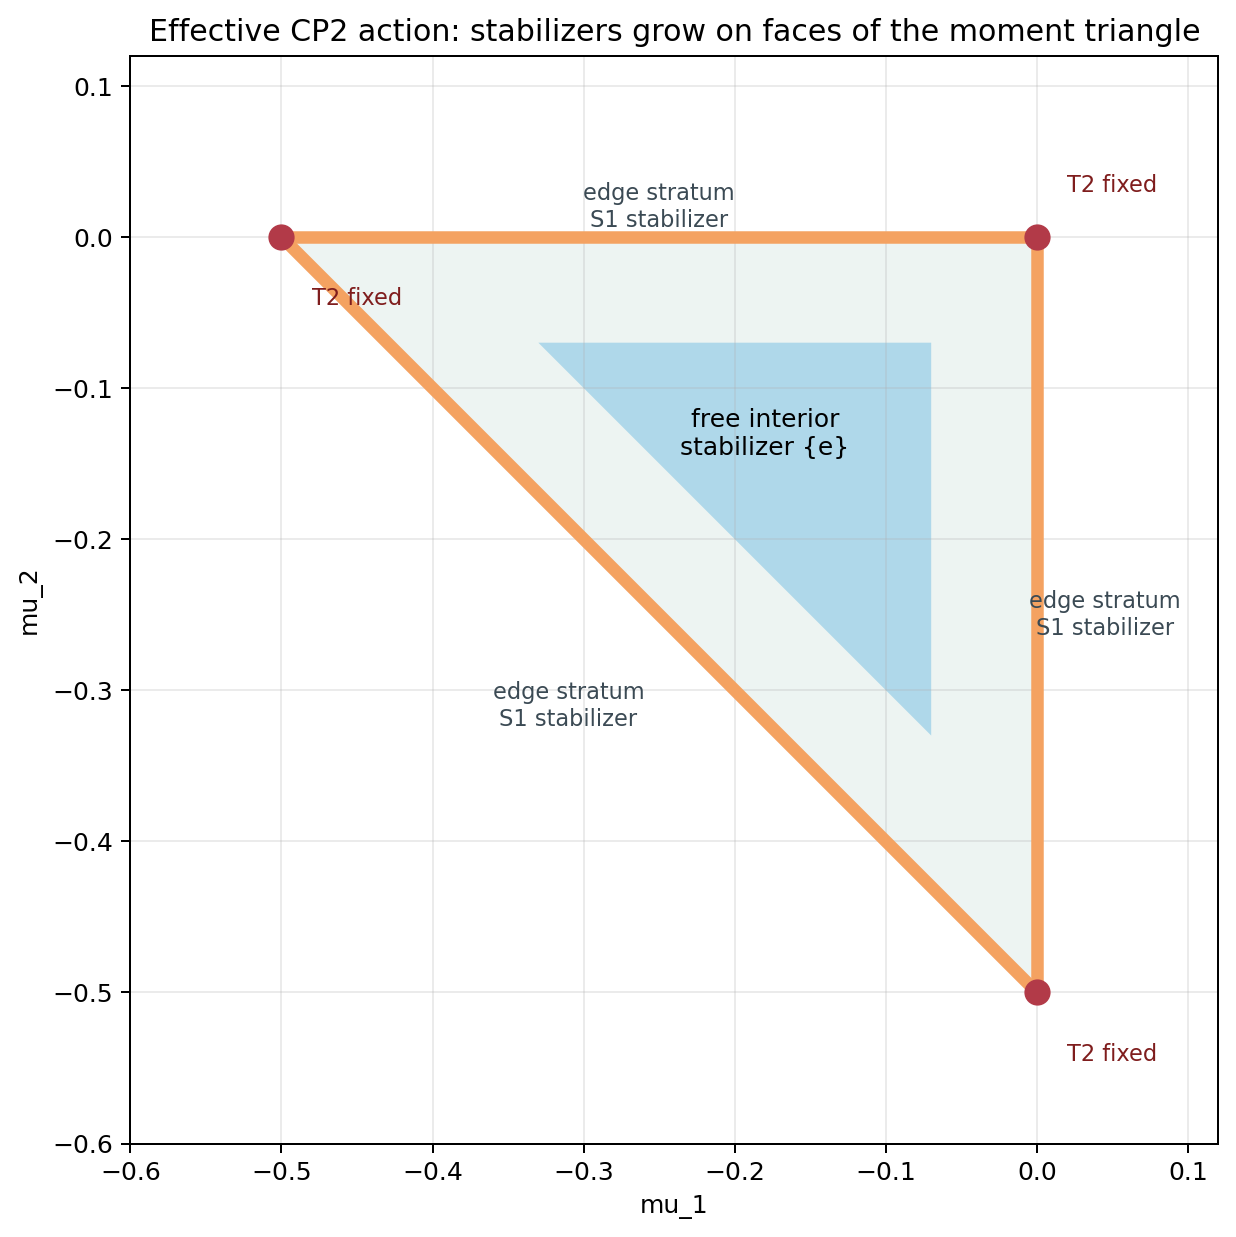

{'example': 'standard T^2 action on CP2',
 'torus_dimension_m': 2,
 'real_dimension_M': 4,
 'dim_M_at_least_2m': True,
 'fixed_point_count': 3,
 'fixed_point_lower_bound_m_plus_1': True,
 'strata': {'interior': {'stabilizer_dimension': 0, 'orbit_dimension': 2},
  'edge': {'stabilizer_dimension': 1, 'orbit_dimension': 1},
  'vertex': {'stabilizer_dimension': 2, 'orbit_dimension': 0}}}

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 7.0))
triangle = vertices["CP2"]
tri_patch = Polygon(triangle, closed=True, facecolor="#edf4f2", edgecolor="#222", linewidth=1.4)
ax.add_patch(tri_patch)

# Interior region.
inner = np.array([[-0.07, -0.07], [-0.33, -0.07], [-0.07, -0.33]])
ax.add_patch(Polygon(inner, closed=True, facecolor="#8ecae6", alpha=0.65, edgecolor="none"))
ax.text(-0.18, -0.13, "free interior\nstabilizer {e}", ha="center", va="center", fontsize=10)

# Edges and vertices.
edge_labels = [
    ((-0.25, 0.02), "edge stratum\nS1 stabilizer"),
    ((0.045, -0.25), "edge stratum\nS1 stabilizer"),
    ((-0.31, -0.31), "edge stratum\nS1 stabilizer"),
]
for (x, y), label in edge_labels:
    ax.text(x, y, label, ha="center", va="center", fontsize=9, color="#3b4a54")
ax.plot([0, -0.5], [0, 0], color="#f4a261", lw=5, solid_capstyle="round")
ax.plot([0, 0], [0, -0.5], color="#f4a261", lw=5, solid_capstyle="round")
ax.plot([-0.5, 0], [0, -0.5], color="#f4a261", lw=5, solid_capstyle="round")
ax.scatter(triangle[:, 0], triangle[:, 1], color="#b23a48", s=90, zorder=3, label="fixed points")
for xy, label in zip(triangle, ["T2 fixed", "T2 fixed", "T2 fixed"]):
    offset = np.array([0.02, 0.03]) if np.allclose(xy, [0,0]) else np.array([0.02, -0.045])
    ax.text(*(xy + offset), label, fontsize=9, color="#7f1d1d")

ax.set_title("Effective CP2 action: stabilizers grow on faces of the moment triangle")
ax.set_xlabel("mu_1")
ax.set_ylabel("mu_2")
ax.set_aspect("equal")
ax.set_xlim(-0.6, 0.12)
ax.set_ylim(-0.6, 0.12)
ax.grid(alpha=0.25)
fig.tight_layout()
strata_path = FIG_DIR / "lecture-27-effective-strata.png"
fig.savefig(strata_path, dpi=180, bbox_inches="tight")
plt.close(fig)

effective_checks = {
    "example": "standard T^2 action on CP2",
    "torus_dimension_m": 2,
    "real_dimension_M": 4,
    "dim_M_at_least_2m": 4 >= 2 * 2,
    "fixed_point_count": 3,
    "fixed_point_lower_bound_m_plus_1": 3 >= 2 + 1,
    "strata": {
        "interior": {"stabilizer_dimension": 0, "orbit_dimension": 2},
        "edge": {"stabilizer_dimension": 1, "orbit_dimension": 1},
        "vertex": {"stabilizer_dimension": 2, "orbit_dimension": 0}
    }
}
write_json(CHECK_DIR / "effective-strata-checks.json", effective_checks)
display_artifact(strata_path, width=700)
effective_checks

## Interactive Simplex Lab

The HTML artifact keeps the projective-space examples in one place. Rotate the CP3 tetrahedron and compare it with the CP2 triangular face. The lesson to inspect is not the 3D rendering itself; it is that the fixed-point images are enough to recover the whole moment image by convex hull.

In [7]:
fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=cp3_samples[:, 0], y=cp3_samples[:, 1], z=cp3_samples[:, 2],
    mode="markers", marker=dict(size=3, color="#2d6f8e", opacity=0.55), name="CP3 samples"
))
fig.add_trace(go.Mesh3d(
    x=vertices["CP3"][:, 0], y=vertices["CP3"][:, 1], z=vertices["CP3"][:, 2],
    i=hull.simplices[:, 0], j=hull.simplices[:, 1], k=hull.simplices[:, 2],
    color="#f5d58a", opacity=0.35, name="fixed-point hull"
))
fig.add_trace(go.Scatter3d(
    x=vertices["CP3"][:, 0], y=vertices["CP3"][:, 1], z=vertices["CP3"][:, 2],
    mode="markers+text", marker=dict(size=7, color="#b23a48"),
    text=["[1,0,0,0]", "[0,1,0,0]", "[0,0,1,0]", "[0,0,0,1]"],
    textposition="top center", name="fixed points"
))
fig.update_layout(
    title="Lecture 27 interactive lab: CP3 moment simplex",
    scene=dict(xaxis_title="mu_1", yaxis_title="mu_2", zaxis_title="mu_3", aspectmode="cube"),
    margin=dict(l=0, r=0, t=45, b=0),
    template="plotly_white",
    height=640
)
html_path = HTML_DIR / "lecture-27-moment-simplex-lab.html"
fig.write_html(html_path, include_plotlyjs=True, full_html=True)
display_artifact(html_path, width=850, height=560)

## Connectedness Scaffold From Homework 21

The lecture uses connectedness as a theorem input, and the following homework explains why it is available for compact Hamiltonian torus actions. The computational translation is:

1. Average a Riemannian metric over the torus, then recover a compatible invariant almost-complex structure.
2. Fixed sets of subtori are symplectic because their tangent spaces are invariant under that complex structure.
3. Components `mu_X = <mu, X>` are Morse-Bott functions; their critical manifolds have even index and coindex.
4. Even index/coindex prevents level sets from splitting during Morse-Bott passage.
5. Induct over the torus dimension to obtain connected moment-map levels.

That is why the line-slice picture above is legitimate: the connected set is not guessed from the picture; it is supplied by the Morse-Bott connectedness result.

In [8]:
connectedness_ledger = {
    "metric_averaging": "torus-invariant metric supplies compatible invariant J",
    "fixed_sets": "subtorus fixed sets are symplectic submanifolds",
    "morse_bott": "mu_X has critical set equal to the fixed set of the closure generated by X",
    "even_indices": "J-invariance makes Hessian eigenspaces even-dimensional",
    "level_connectedness": "Morse-Bott level sets remain connected, then induction handles R^m moment maps",
    "used_in_lecture_27": "A_{m-1} connectedness input for the subtorus slice proof of B_m"
}
write_json(CHECK_DIR / "connectedness-ledger.json", connectedness_ledger)
connectedness_ledger

{'metric_averaging': 'torus-invariant metric supplies compatible invariant J',
 'fixed_sets': 'subtorus fixed sets are symplectic submanifolds',
 'morse_bott': 'mu_X has critical set equal to the fixed set of the closure generated by X',
 'even_indices': 'J-invariance makes Hessian eigenspaces even-dimensional',
 'level_connectedness': 'Morse-Bott level sets remain connected, then induction handles R^m moment maps',
 'used_in_lecture_27': 'A_{m-1} connectedness input for the subtorus slice proof of B_m'}

## Final Sanity Checks And Takeaways

The final cell reads every generated check, asserts the mathematical booleans that matter for the lecture, and verifies that the artifacts displayed above exist with nonzero size.

Takeaways:

- Convexity is proved by turning connected projected fibers into line segments in the moment image.
- The fixed-point images are not just examples; they are the vertices whose convex hull is the whole image.
- Effective Hamiltonian torus actions force enough fixed points and enough ambient symplectic dimension.
- The CP examples are the first visual bridge to Delzant polytopes and symplectic toric manifolds.

In [9]:
artifact_paths = [
    proof_route_path,
    cp_path,
    slice_path,
    strata_path,
    html_path,
]
check_paths = [
    CHECK_DIR / "source-span.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "proof-route-checks.json",
    CHECK_DIR / "moment-polytope-checks.json",
    CHECK_DIR / "subtorus-slicing-checks.json",
    CHECK_DIR / "effective-strata-checks.json",
    CHECK_DIR / "connectedness-ledger.json",
]

proof_checks = read_json(CHECK_DIR / "proof-route-checks.json")
moment_checks = read_json(CHECK_DIR / "moment-polytope-checks.json")
slice_checks = read_json(CHECK_DIR / "subtorus-slicing-checks.json")
effective_checks = read_json(CHECK_DIR / "effective-strata-checks.json")

assert proof_checks["is_directed_acyclic_graph"]
assert all(proof_checks["reachable_theorem_claims"].values())
assert moment_checks["CP1"]["inside_interval"]
assert moment_checks["CP2"]["all_samples_inside_fixed_point_hull"]
assert moment_checks["CP3"]["all_samples_inside_fixed_point_hull"]
assert slice_checks["max_projected_level_spread"] < 1e-12
assert slice_checks["midpoint_on_segment"]
assert slice_checks["inside_CP2_moment_triangle"]
assert effective_checks["dim_M_at_least_2m"]
assert effective_checks["fixed_point_lower_bound_m_plus_1"]

for path in artifact_paths + check_paths:
    assert path.exists(), f"missing: {path}"
    assert path.stat().st_size > 0, f"empty: {path}"

final_sanity = {
    "passed": True,
    "status": "passed",
    "source_pages_actually_read": source_span,
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": [rel(path) for path in check_paths],
    "mathematical_assertions": {
        "proof_route_is_acyclic": proof_checks["is_directed_acyclic_graph"],
        "convexity_claims_reachable": all(proof_checks["reachable_theorem_claims"].values()),
        "CP2_samples_inside_fixed_point_hull": moment_checks["CP2"]["all_samples_inside_fixed_point_hull"],
        "CP3_samples_inside_fixed_point_hull": moment_checks["CP3"]["all_samples_inside_fixed_point_hull"],
        "subtorus_slice_projection_constant": slice_checks["max_projected_level_spread"] < 1e-12,
        "effective_CP2_meets_dimension_bound": effective_checks["dim_M_at_least_2m"],
        "effective_CP2_meets_fixed_point_bound": effective_checks["fixed_point_lower_bound_m_plus_1"]
    }
}
final_sanity["assertions"] = {key: bool(value) for key, value in final_sanity["mathematical_assertions"].items()}
write_json(CHECK_DIR / "final-sanity.json", final_sanity)
final_sanity

{'passed': True,
 'status': 'passed',
 'source_pages_actually_read': {'lecture': 'Lecture 27: Convexity',
  'pdf_extraction_tool': 'pdftotext',
  'physical_pdf_pages_read': '178-184',
  'printed_pages_read': '168-174',
  'lecture_pages': '168-172',
  'homework_pages_used_for_connectedness_scaffold': '173-174',
  'source_map_note': 'The inventory span 182-188 starts at printed page 172 and spills into Lecture 28; page headers show 178-184 is the usable Convexity span.'},
 'artifacts': ['artifacts/lecture-27/figures/lecture-27-convexity-proof-route.png',
  'artifacts/lecture-27/figures/lecture-27-cp-moment-polytopes.png',
  'artifacts/lecture-27/figures/lecture-27-subtorus-slicing.png',
  'artifacts/lecture-27/figures/lecture-27-effective-strata.png',
  'artifacts/lecture-27/interactive/lecture-27-moment-simplex-lab.html'],
 'checks': ['artifacts/lecture-27/checks/source-span.json',
  'artifacts/lecture-27/checks/visual-storyboard.json',
  'artifacts/lecture-27/checks/proof-route-checks.